In [2]:
import pandas as pd

df = pd.read_parquet('../data/PlayerStatistics.parquet')
df_len = len(df)
print(df_len)

1668439


In [3]:
df['numMinutes'].isna().sum()

np.int64(168336)

In [4]:
df = df.dropna(subset=['numMinutes'])
print(len(df))

1500103


# Convert numMinutes to a float

In [5]:
converted = pd.to_numeric(df['numMinutes'], errors='coerce')

bad_mask = converted.isna() & df['numMinutes'].notna()  # rows that failed conversion
bad_rows = df.loc[bad_mask, 'numMinutes']
print(bad_rows)

1665874    24:50
1665875     6:05
1665876     8:02
1665877     3:19
1665878    36:10
           ...  
1668433    21:16
1668434    16:01
1668435    33:10
1668436    20:30
1668438    13:25
Name: numMinutes, Length: 2097, dtype: string


In [6]:
df['numMinutes'] = df['numMinutes'].astype('object')

s = df['numMinutes'].astype(str)

split = s[bad_mask].str.split(':', expand=True)

df.loc[bad_mask, 'numMinutes'] = (
    pd.to_numeric(split[0], errors='coerce') +
    pd.to_numeric(split[1], errors='coerce') / 60
)

In [7]:
df['numMinutes'].isna().sum()

np.int64(0)

In [8]:
df = df[(df['gameType'] != 'Preseason') & (df['gameType'] != 'Pre Season')]

# Drop Player-Games that Played Fewer than _x_ minutes or did not attempt a FGA

In [9]:
NUM_MINUTES_FLOOR = 10

df['numMinutes'] = df['numMinutes'].astype('float32')
df = df[df['numMinutes'] >= NUM_MINUTES_FLOOR]
print(len(df))

df = df[df['fieldGoalsAttempted'] > 0]
print(len(df))

1146601
1138199


In [10]:
# Drop Data before the 1973-74 season because there are no steals/blocks data using gameDate, which is an object
# Drop Data before 1982-83 season bc lot of team stats like total FGAs weren't recorded
df = df.dropna(subset=['gameDate'])
df['gameDate'] = pd.to_datetime(df['gameDate'], errors='coerce')
print(df['gameDate'].isna().sum())

# First date of 1973-74 season was October 9, 1973
cutoff = pd.Timestamp('1983-10-27')
df = df[df['gameDate'] >= cutoff].copy()
print(len(df))

0
907665


In [11]:
# Dropping Categorical Data Related to Teams
df = df.drop(columns=['playerteamCity', 'opponentteamCity', 'opponentteamName'])

In [12]:
df.columns

Index(['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst',
       'playerteamName', 'gameType', 'win', 'home', 'numMinutes', 'points',
       'assists', 'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade',
       'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade',
       'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',
       'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints',
       'playerteamId', 'opponentteamId', 'comment', 'gameDate'],
      dtype='object')

# Converting Box Score Data to Per-36

In [13]:
cols_to_convert_per36 = ['points', 'assists', 'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade', 
                         'threePointersAttempted', 'threePointersMade', 'freeThrowsAttempted', 'freeThrowsMade', 
                         'reboundsDefensive', 'reboundsOffensive', 'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints']
per36_convert = lambda x: x/df['numMinutes']
for c in cols_to_convert_per36:
    df[f'{c}_per36'] = per36_convert(df[c])

In [14]:
df.columns

Index(['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst',
       'playerteamName', 'gameType', 'win', 'home', 'numMinutes', 'points',
       'assists', 'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade',
       'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade',
       'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',
       'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints',
       'playerteamId', 'opponentteamId', 'comment', 'gameDate', 'points_per36',
       'assists_per36', 'blocks_per36', 'steals_per36',
       'fieldGoalsAttempted_per36', 'fieldGoalsMade_per36',
       'threePointersAttempted_per36', 'threePointersMade_per36',
       'freeThrowsAttempted_per36', 'freeThrowsMade_per36',
       'reboundsDefensive_per36', 'reboundsOffensive_per36',
       'reboundsTotal_per36', 'foulsPersonal_per36', 'turnovers_per36',
       'plusMinusP

In [15]:
import numpy as np

df["season"] = np.where(
    df["gameDate"].dt.month >= 10,
    df["gameDate"].dt.year + 1,
    df["gameDate"].dt.year
)
df.loc[
    (df["gameDate"] >= "2020-10-01") & (df["gameDate"] <= "2020-12-01"),
    "season"
] = 2020

# Merging Team Data into the DataFrame

In [ ]:
team_stats = pd.read_parquet('../data/TeamStatistics.parquet')
team_stats = team_stats.rename(columns={
    'teamId': 'playerteamId',
    'teamName': 'playerteamName'
})
print(len(df.columns))
df = df.merge(team_stats, on=['gameId', 'playerteamName'], suffixes = ['_player', '_team'])
print(len(df.columns))

In [18]:
df = df.drop(columns=['teamCity', 'opponentTeamCity', 'opponentTeamName', 'opponentTeamId', 'home_team',
                      'win_team', 'biggestLead', 'biggestScoringRun', 'leadChanges', 'q1Points', 
                      'q2Points', 'q3Points', 'q4Points', 'ot1Points', 'ot2Points', 'otAllPoints'])
df['pointDifferential'] = df['teamScore'] - df['opponentScore']
df['winPercent_team'] = (
    df['seasonWins'] / (df['seasonWins'] + df['seasonLosses'])
).where((df['seasonWins'] + df['seasonLosses']) > 0, 0.0)
df = df.rename(columns={
    'teamScore': 'points_team',
    'points': 'points_player'
})

df = df.drop(columns=['opponentScore', 'seasonWins', 'seasonLosses', 'gameLabel', 'gameType_team', 'gameSubLabel',
                      'seriesGameNumber', 'seed', 'gameDate_team', 'opponentteamId',
                      'timesTied', 'timeoutsRemaining', 'gameDateTimeEst_team', 'gameDate_player'])

# Feature Engineering

In [19]:
percent_col_prefixes = ['points', 'assists', 'steals',
                        'fieldGoalsAttempted', 'fieldGoalsMade', 
                        'freeThrowsAttempted', 'freeThrowsMade',
                        'reboundsDefensive', 'reboundsOffensive',
                        'reboundsTotal', 'foulsPersonal', 'turnovers']

# Drop players who we don't have full team stats for
orig_len = len(df)
drop_na_cols = [f'{c}_team' for c in percent_col_prefixes]
df = df.dropna(subset=drop_na_cols, how='any')

for p in percent_col_prefixes:
    df = df[df[f'{p}_player'] <= df[f'{p}_team']].copy() # Consistency Check
    df[f'{p}Percent'] = df[f'{p}_player'] / df[f'{p}_team']
print(f'{orig_len - len(df)} rows dropped.')

df['fgRelativePercent'] = df['fieldGoalsPercentage_player'] - df['fieldGoalsPercentage_team']
df['3pRelativePercent'] = df['threePointersPercentage_player'] - df['threePointersPercentage_team']
df['ftRelativePercent'] = df['freeThrowsPercentage_player'] - df['freeThrowsPercentage_team']

33351 rows dropped.


In [20]:
df['3PA_rate'] = df['threePointersAttempted_player'] / df['fieldGoalsAttempted_player']
df['trueShooting'] = df['points_player'] / (2 *
                                     (df['fieldGoalsAttempted_player'] + 0.44 *
                                      df['freeThrowsAttempted_player']))
df['eFG'] = (df['fieldGoalsMade_player'] + 0.5 * df['threePointersMade_player'])/df['fieldGoalsAttempted_player']
df['FTA_rate'] = df['freeThrowsAttempted_player'] / df['fieldGoalsAttempted_player']

In [21]:
df['USG'] = ((df['fieldGoalsAttempted_player'] +
              0.44 * df['freeThrowsAttempted_player'] +
              df['turnovers_player']) * df['numMinutes_team']) / (
                  5 * df['numMinutes_player'] *
                  (df['fieldGoalsAttempted_team'] + 0.44 * 
                   df['freeThrowsAttempted_team'] + 
                   df['turnovers_team'])
              ) * 100


In [22]:
df["USG"].quantile([0.01, 0.5, 0.99])

0.01     4.672897
0.50    19.343423
0.99    38.495485
Name: USG, dtype: float64

# Finally, combine this with their actual positions

In [23]:
position_data = pd.read_parquet('../data/Player Positions.parquet')

# He played playoff games but no regular season hence isn't in Basketball Reference regular season data
position_data_extended = pd.read_excel('../data/Extra Player Positions.xlsx')
position_data = pd.concat([position_data, position_data_extended])

In [24]:
position_data.head()

,Player,Pos,Team,Season
0,Bob McAdoo,C,BUF,1974
1,Kareem Abdul-Jabbar,C,MIL,1974
2,Pete Maravich,SG,ATL,1974
3,Gail Goodrich,SG,LAL,1974
4,Rick Barry,SF,GSW,1974


In [25]:
player_renaming = pd.read_excel('../data/Manual Player Renaming.xlsx')
player_renaming.tail(2)

,Position Data Name,df Name
103,Michael Wilson,Mike Wilson
104,Chaundee Brown Jr.,Chaundee Brown


In [26]:
rename_map = dict(
    zip(player_renaming['Position Data Name'].str.strip().str.lower(),
        player_renaming['df Name'].str.strip().str.lower())
)
df["full_name"] = (
    df["firstName"].str.strip() + " " + df["lastName"].str.strip()
)
df['full_name'] = df['full_name'].replace({
    'ga Bitadze': 'Goga Bitadze',
    'Jimmy Butler III': "Jimmy Butler",
    'Nigel Hayes': 'Nigel Hayes-Davis',
    'Charles R. Jones': 'Charles Jones'
})

# clean name columns
df["full_name"] = df["full_name"].str.lower().str.strip()
df.loc[
    (df["full_name"] == "jeffery taylor") & (df["season"] >= 2011),
    "full_name"
] = "jeff taylor"
position_data["full_name"] = position_data["Player"].str.lower().str.strip()
position_data['full_name'] = position_data['full_name'].replace(rename_map)

position_map = (position_data
                .drop_duplicates(['full_name', 'Season'])
                .set_index(['full_name', 'Season'])['Pos']
)
df["Position"] = df.set_index(
    ["full_name", 'season']
).index.map(position_map)

missing_players = (
    df[df["Position"].isna()][["firstName", "lastName", 'season']]
    .drop_duplicates()
    .sort_values(["lastName", "firstName"])
)

if not missing_players.empty:
    print("Players missing positions:")
    print(missing_players.to_string(index=False))
else:
    print("All players matched to positions.")

All players matched to positions.


In [27]:
len(missing_players)

0

In [28]:
df['Position'].value_counts()

Position
SG    186412
PF    178455
PG    174439
SF    168619
C     165569
F         88
Name: count, dtype: int64

In [29]:
df[df['season'] == 2022]['Position'].value_counts()

Position
SG    5709
PF    4643
C     4474
SF    4439
PG    4358
Name: count, dtype: int64

In [30]:
df = df[df['Position'] != 'F'] # No singular position provided

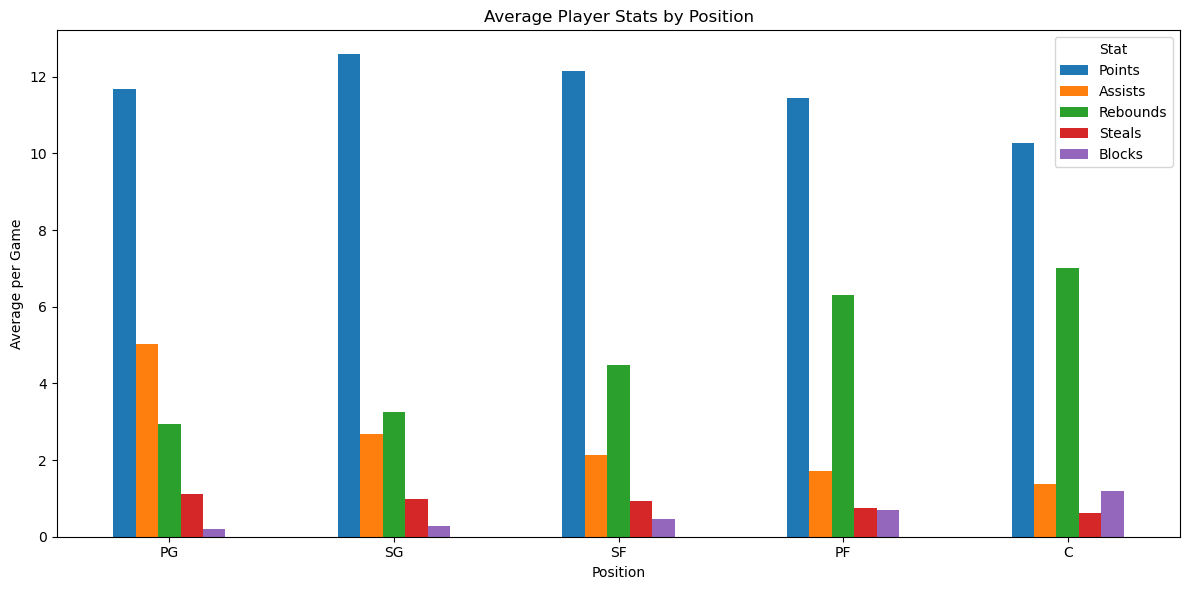

In [31]:
import matplotlib.pyplot as plt

stats = [
    "points_player",
    "assists_player",
    "reboundsTotal_player",
    "steals_player",
    "blocks_player",
]

# average by position
position_means = (
    df.groupby("Position")[stats]
    .mean()
    .reindex(['PG','SG', 'SF', 'PF','C'])
)

position_means = position_means.rename(columns={
    "points_player": "Points",
    "assists_player": "Assists",
    "reboundsTotal_player": "Rebounds",
    "steals_player": "Steals",
    "blocks_player": "Blocks"
})

# plot
position_means.plot(kind="bar", figsize=(12, 6))

plt.ylabel("Average per Game")
plt.title("Average Player Stats by Position")
plt.xticks(rotation=0)
plt.legend(title="Stat")
plt.tight_layout()
plt.show()

In [32]:
df = df.drop(columns=['full_name'])
df.to_parquet('../data/Processed Positions Data.parquet')